In [3]:
!pip -q install pyreadstat

import pandas as pd
import pyreadstat
from google.colab import files

In [4]:
uploaded = files.upload()

Saving EH2025_Vivienda_1.sav to EH2025_Vivienda_1.sav
Saving EH2025_Persona.sav to EH2025_Persona.sav


In [5]:
persona, meta_persona = pyreadstat.read_sav(
    "EH2025_Persona.sav",
    apply_value_formats=False
)

vivienda, meta_vivienda = pyreadstat.read_sav(
    "EH2025_Vivienda_1.sav",
    apply_value_formats=False
)

print("PERSONA:", persona.shape)
print("VIVIENDA:", vivienda.shape)

print("\nValores de cmasi:")
print(persona["cmasi"].value_counts(dropna=False).sort_index())

print("\nEtiquetas de cmasi:")
print(meta_persona.variable_value_labels.get("cmasi"))

PERSONA: (39485, 276)
VIVIENDA: (12726, 64)

Valores de cmasi:
cmasi
1.0    23864
2.0    13576
3.0       45
NaN     2000
Name: count, dtype: int64

Etiquetas de cmasi:
{1.0: 'No matriculado', 2.0: 'Asiste', 3.0: 'No asiste'}


In [6]:
escolar = persona[
    persona["s01a_03"].between(6, 19) &
    persona["cmasi"].isin([1.0, 2.0, 3.0])
].copy()

escolar["Asistencia_Escolar"] = escolar["cmasi"].map({
    1.0: 0,   # No matriculado
    2.0: 1,   # Asiste
    3.0: 0    # No asiste
})

print("Total población 6-19 años:", len(escolar))
print("\nVariable objetivo:")
print(escolar["Asistencia_Escolar"].value_counts())

print("\nPorcentaje:")
print(escolar["Asistencia_Escolar"].value_counts(normalize=True) * 100)

Total población 6-19 años: 10450

Variable objetivo:
Asistencia_Escolar
1    9905
0     545
Name: count, dtype: int64

Porcentaje:
Asistencia_Escolar
1    94.784689
0     5.215311
Name: proportion, dtype: float64


In [7]:
def buscar_variables(meta, palabras):
    for col, etiqueta in meta.column_names_to_labels.items():
        texto = f"{col} {etiqueta}".lower()
        if any(p.lower() in texto for p in palabras):
            print(f"{col:20} | {etiqueta}")

print("=== PERSONA ===")
buscar_variables(
    meta_persona,
    ["edad", "sexo", "idioma", "indígen", "indigena",
     "ingreso", "departamento", "área", "area",
     "municipio", "folio"]
)

print("\n=== VIVIENDA ===")
buscar_variables(
    meta_vivienda,
    ["agua", "electricidad", "energía", "energia",
     "piso", "departamento", "área", "area",
     "municipio", "folio"]
)

=== PERSONA ===
folio                | Id hogar anonimizado
area                 | Urbana Rural
depto                | Departamento
s01a_07_1            | ¿Qué idiomas habla?, según el mayor uso: 1°
s01a_07_2            | ¿Qué idiomas habla?, según el mayor uso: 2°
s01a_07_3            | ¿Qué idiomas habla?, según el mayor uso: 3°
s01a_08              | ¿Cuál es el primer idioma o lengua en el que aprendió a hablar en su niñez?
s01a_09              | ¿Se autoidentifica con alguna nación pueblo indígena originario campesino o afroboliviano?
s01a_09npioc         | ¿Se autoidentifica con alguna nación pueblo indígena originario campesino o afroboliviano? ¿Con cuál?
s01b_11b             | Especifique el Departamento  dónde vivía hace 5 años (2020)
s01b_11d             | Especifique el Municipio dónde vivía hace 5 años (2020)
s04c_21a             | Además de los ingresos recibidos en dinero por su trabajo, en los últimos doce meses ¿recibió, usted… A. Alimentos y bebidas para ser consumidos

In [8]:
datos = escolar.merge(
    vivienda[[
        "folio",
        "s06a_06",
        "s06a_07",
        "s06a_12"
    ]],
    on="folio",
    how="left"
)

variables = [
    "Asistencia_Escolar",
    "s01a_03",
    "s01a_02",
    "area",
    "depto",
    "s01a_07_1",
    "s01a_09",
    "yhogpc",
    "niv_ed",
    "s06a_06",
    "s06a_07",
    "s06a_12"
]

modelo = datos[variables].copy()

print("Dimensión:", modelo.shape)
print("\nValores faltantes:")
print(modelo.isnull().sum())

Dimensión: (10450, 12)

Valores faltantes:
Asistencia_Escolar    0
s01a_03               0
s01a_02               0
area                  0
depto                 0
s01a_07_1             0
s01a_09               0
yhogpc                2
niv_ed                0
s06a_06               0
s06a_07               0
s06a_12               0
dtype: int64


In [9]:
modelo = modelo.dropna(subset=["yhogpc"]).copy()

duplicados = modelo.duplicated().sum()

print("Dimensión después de limpiar:", modelo.shape)
print("Valores faltantes:", modelo.isnull().sum().sum())
print("Filas duplicadas:", duplicados)

Dimensión después de limpiar: (10448, 12)
Valores faltantes: 0
Filas duplicadas: 65


In [10]:
print("Personas duplicadas por folio+nro:",
      datos.duplicated(subset=["folio", "nro"]).sum())

print("Folios duplicados en Vivienda:",
      vivienda["folio"].duplicated().sum())

print("Registros actuales:", len(modelo))

Personas duplicadas por folio+nro: 0
Folios duplicados en Vivienda: 0
Registros actuales: 10448


In [11]:
vars_etiquetas = [
    "s01a_02",   # sexo
    "area",
    "depto",
    "s01a_07_1", # idioma
    "s01a_09",   # autoidentificación
    "niv_ed",
    "s06a_06",   # piso
    "s06a_07",   # agua
    "s06a_12"    # electricidad
]

for v in vars_etiquetas:
    etiquetas = (
        meta_persona.variable_value_labels.get(v)
        if v in persona.columns
        else meta_vivienda.variable_value_labels.get(v)
    )
    print(f"\n{v}:")
    print(etiquetas)


s01a_02:
{1.0: '1. Hombre', 2.0: '2. Mujer'}

area:
None

depto:
{1.0: 'Chuquisaca', 2.0: 'La Paz', 3.0: 'Cochabamba', 4.0: 'Oruro', 5.0: 'Potosí', 6.0: 'Tarija', 7.0: 'Santa Cruz', 8.0: 'Beni', 9.0: 'Pando'}

s01a_07_1:
{1.0: '001  ARAONA', 2.0: '002  AYMARA', 3.0: '003  BAURE', 4.0: '004  BÉSIRO', 5.0: '005  CANICHANA', 6.0: '006  CASTELLANO', 7.0: '007  KABINEÑA', 8.0: '008  CAYUBABA', 9.0: '009  CHÁCOBO', 10.0: '010  TSIMANE´', 11.0: '011  ESE EJJA', 12.0: '012  GUARANÍ', 13.0: "013  GUARASU'WE", 14.0: '014  GWARAYU', 15.0: '015  ITONAMA', 16.0: '016  LECO', 17.0: '017  MACHA´JUYAI KALLAWAYA', 18.0: '018  MACHINERI', 19.0: '019  MAROPA', 20.0: '020  MOJEÑO IGNACIANO', 21.0: '021  MOJEÑO TRINITARIO', 22.0: '022  MORÉ', 23.0: '023  MOSETÉN', 24.0: '024  MOVIMA', 25.0: '025  PACAHUARA', 26.0: '026  PUQUINA', 27.0: '027  QUECHUA', 28.0: '028  SIRIONÓ', 29.0: '029  TACANA', 30.0: '030  TAPIETE', 31.0: '031  TOROMONA', 32.0: '032  URU-CHIPAYA', 33.0: '033  WEENHAYEK', 34.0: '034  YAMINA

In [12]:
print("Valores de AREA:")
print(modelo["area"].value_counts(dropna=False).sort_index())

print("\nEtiqueta de la variable:")
print(meta_persona.column_names_to_labels.get("area"))

print("\nValores únicos:")
print(modelo["area"].unique())

Valores de AREA:
area
1.0    7884
2.0    2564
Name: count, dtype: int64

Etiqueta de la variable:
Urbana Rural

Valores únicos:
[1. 2.]


=== RESUMEN GENERAL ===
Registros analizados: 10448
Edad mínima: 6.0
Edad máxima: 19.0
Ingreso per cápita promedio: 1433.49
Ingreso per cápita mediano: 1122.5

=== ASISTENCIA ESCOLAR ===
Asistencia
Asiste       9904
No asiste     544
Name: count, dtype: int64

=== PORCENTAJES ===
Asistencia
Asiste       94.79
No asiste     5.21
Name: proportion, dtype: float64


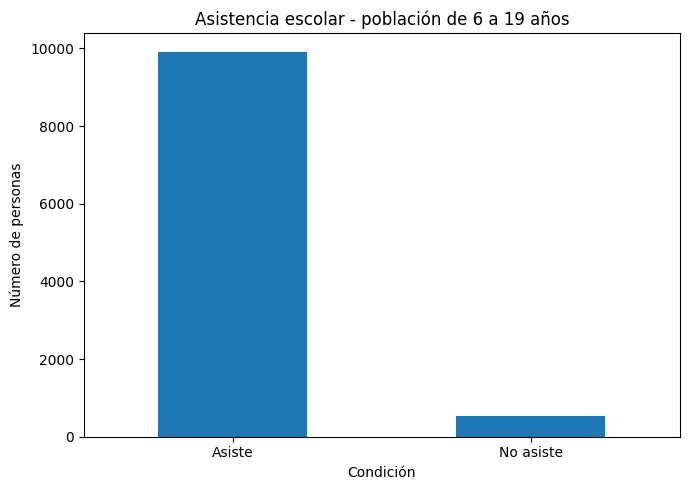


=== TASA DE NO ASISTENCIA POR SEXO (%) ===
Sexo
Hombre    5.44
Mujer     4.97
Name: No_Asiste, dtype: float64


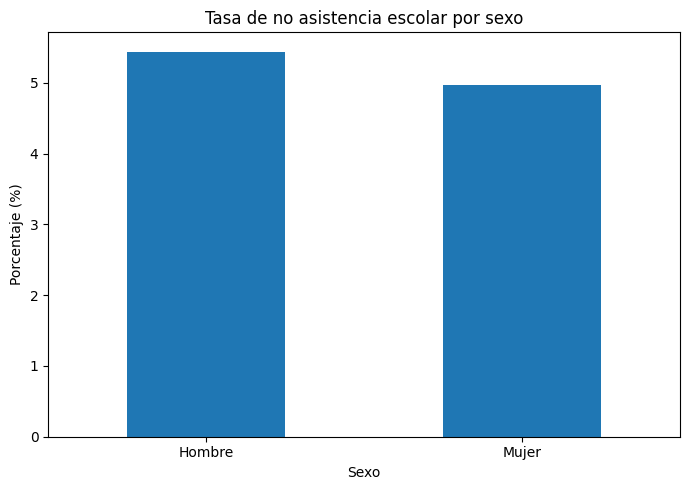


=== TASA DE NO ASISTENCIA POR ÁREA (%) ===
Area
Rural     8.93
Urbana    4.00
Name: No_Asiste, dtype: float64


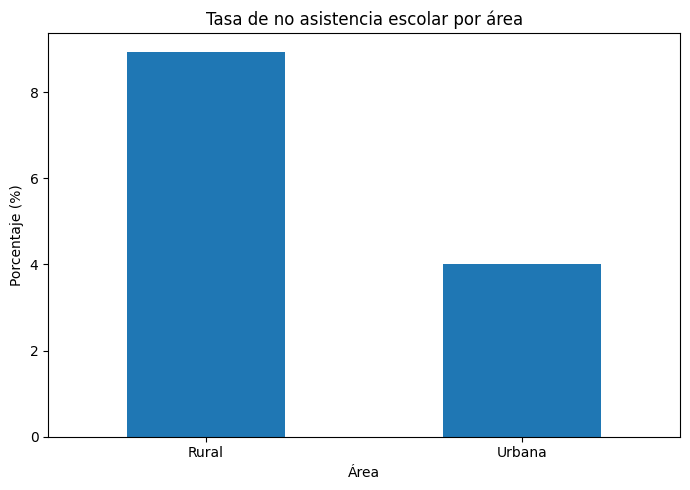


=== TASA DE NO ASISTENCIA POR DEPARTAMENTO (%) ===
Departamento
Cochabamba    3.63
Oruro         4.09
La Paz        4.55
Potosí        5.30
Chuquisaca    5.50
Tarija        5.72
Beni          5.86
Santa Cruz    6.11
Pando         8.01
Name: No_Asiste, dtype: float64


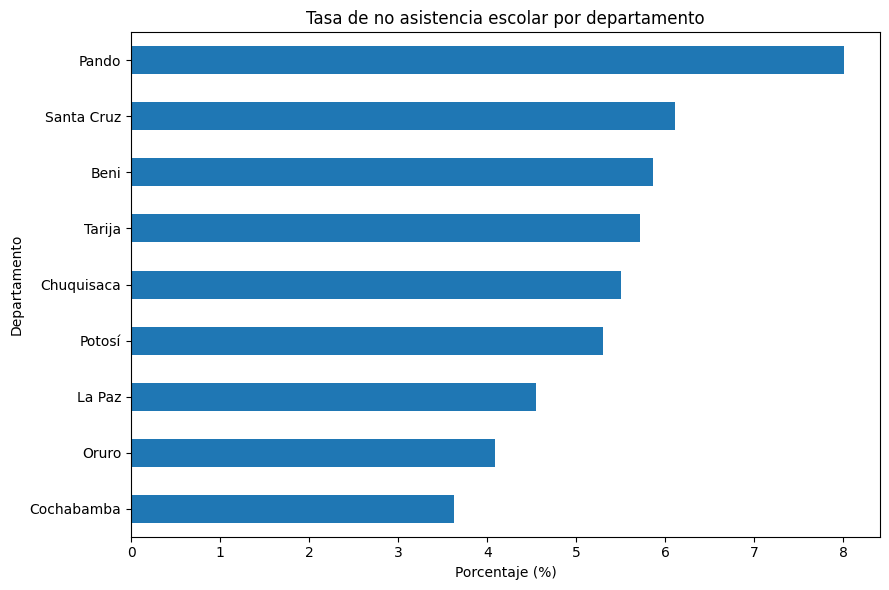


=== TASA DE NO ASISTENCIA POR EDAD (%) ===
s01a_03
6.0      2.23
7.0      0.44
8.0      0.64
9.0      0.44
10.0     0.81
11.0     0.85
12.0     0.73
13.0     1.94
14.0     2.62
15.0     3.57
16.0     4.99
17.0     8.12
18.0    18.73
19.0    37.18
Name: No_Asiste, dtype: float64


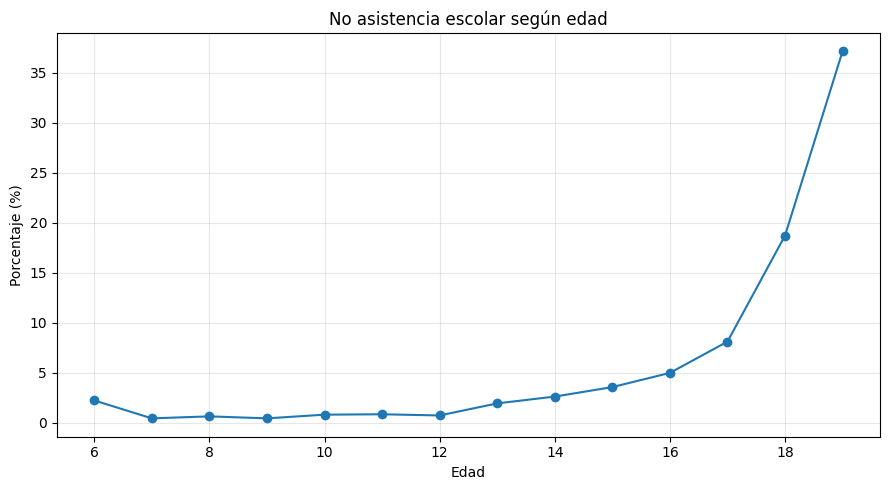


EDA COMPLETADO CORRECTAMENTE


In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. PREPARAR VARIABLES PARA EL ANÁLISIS EXPLORATORIO
# ============================================================

eda = modelo.copy()

eda["Asistencia"] = eda["Asistencia_Escolar"].map({
    1: "Asiste",
    0: "No asiste"
})

eda["No_Asiste"] = 1 - eda["Asistencia_Escolar"]

eda["Sexo"] = eda["s01a_02"].map({
    1.0: "Hombre",
    2.0: "Mujer"
})

eda["Area"] = eda["area"].map({
    1.0: "Urbana",
    2.0: "Rural"
})

departamentos = {
    1.0: "Chuquisaca",
    2.0: "La Paz",
    3.0: "Cochabamba",
    4.0: "Oruro",
    5.0: "Potosí",
    6.0: "Tarija",
    7.0: "Santa Cruz",
    8.0: "Beni",
    9.0: "Pando"
}

eda["Departamento"] = eda["depto"].map(departamentos)

# ============================================================
# 2. RESUMEN GENERAL
# ============================================================

print("=== RESUMEN GENERAL ===")
print("Registros analizados:", len(eda))
print("Edad mínima:", eda["s01a_03"].min())
print("Edad máxima:", eda["s01a_03"].max())
print("Ingreso per cápita promedio:", round(eda["yhogpc"].mean(), 2))
print("Ingreso per cápita mediano:", round(eda["yhogpc"].median(), 2))

print("\n=== ASISTENCIA ESCOLAR ===")
print(eda["Asistencia"].value_counts())

print("\n=== PORCENTAJES ===")
print(
    (eda["Asistencia"].value_counts(normalize=True) * 100)
    .round(2)
)

# ============================================================
# 3. GRÁFICO 1 - DISTRIBUCIÓN DE ASISTENCIA
# ============================================================

tabla_asistencia = eda["Asistencia"].value_counts()

plt.figure(figsize=(7,5))
tabla_asistencia.plot(kind="bar")
plt.title("Asistencia escolar - población de 6 a 19 años")
plt.xlabel("Condición")
plt.ylabel("Número de personas")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("01_asistencia_escolar.png", dpi=300)
plt.show()

# ============================================================
# 4. GRÁFICO 2 - TASA DE NO ASISTENCIA POR SEXO
# ============================================================

sexo = (
    eda.groupby("Sexo")["No_Asiste"]
    .mean()
    .mul(100)
    .round(2)
)

print("\n=== TASA DE NO ASISTENCIA POR SEXO (%) ===")
print(sexo)

plt.figure(figsize=(7,5))
sexo.plot(kind="bar")
plt.title("Tasa de no asistencia escolar por sexo")
plt.xlabel("Sexo")
plt.ylabel("Porcentaje (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("02_no_asistencia_sexo.png", dpi=300)
plt.show()

# ============================================================
# 5. GRÁFICO 3 - TASA DE NO ASISTENCIA POR ÁREA
# ============================================================

area_tabla = (
    eda.groupby("Area")["No_Asiste"]
    .mean()
    .mul(100)
    .round(2)
)

print("\n=== TASA DE NO ASISTENCIA POR ÁREA (%) ===")
print(area_tabla)

plt.figure(figsize=(7,5))
area_tabla.plot(kind="bar")
plt.title("Tasa de no asistencia escolar por área")
plt.xlabel("Área")
plt.ylabel("Porcentaje (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("03_no_asistencia_area.png", dpi=300)
plt.show()

# ============================================================
# 6. GRÁFICO 4 - TASA POR DEPARTAMENTO
# ============================================================

depto_tabla = (
    eda.groupby("Departamento")["No_Asiste"]
    .mean()
    .mul(100)
    .sort_values()
    .round(2)
)

print("\n=== TASA DE NO ASISTENCIA POR DEPARTAMENTO (%) ===")
print(depto_tabla)

plt.figure(figsize=(9,6))
depto_tabla.plot(kind="barh")
plt.title("Tasa de no asistencia escolar por departamento")
plt.xlabel("Porcentaje (%)")
plt.ylabel("Departamento")
plt.tight_layout()
plt.savefig("04_no_asistencia_departamento.png", dpi=300)
plt.show()

# ============================================================
# 7. GRÁFICO 5 - RELACIÓN ENTRE EDAD Y NO ASISTENCIA
# ============================================================

edad_tabla = (
    eda.groupby("s01a_03")["No_Asiste"]
    .mean()
    .mul(100)
    .round(2)
)

print("\n=== TASA DE NO ASISTENCIA POR EDAD (%) ===")
print(edad_tabla)

plt.figure(figsize=(9,5))
edad_tabla.plot(kind="line", marker="o")
plt.title("No asistencia escolar según edad")
plt.xlabel("Edad")
plt.ylabel("Porcentaje (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("05_no_asistencia_edad.png", dpi=300)
plt.show()

print("\nEDA COMPLETADO CORRECTAMENTE")

=== PERFIL DE LOS CLUSTERS ===
         Personas  Edad_promedio  Ingreso_pc_mediano  Rural_pct  \
Cluster                                                           
0            4070           9.18             1178.33       5.04   
1            2200          12.06              619.33      97.68   
2            4178          15.83             1352.22       5.03   

         Electricidad_pct  Agua_red_pct  Autoidentifica_pct  No_asistencia_pct  
Cluster                                                                         
0                   99.85         87.89                5.50               1.01  
1                   88.18          8.45               25.68               8.27  
2                   99.88         88.20                9.12               7.68  


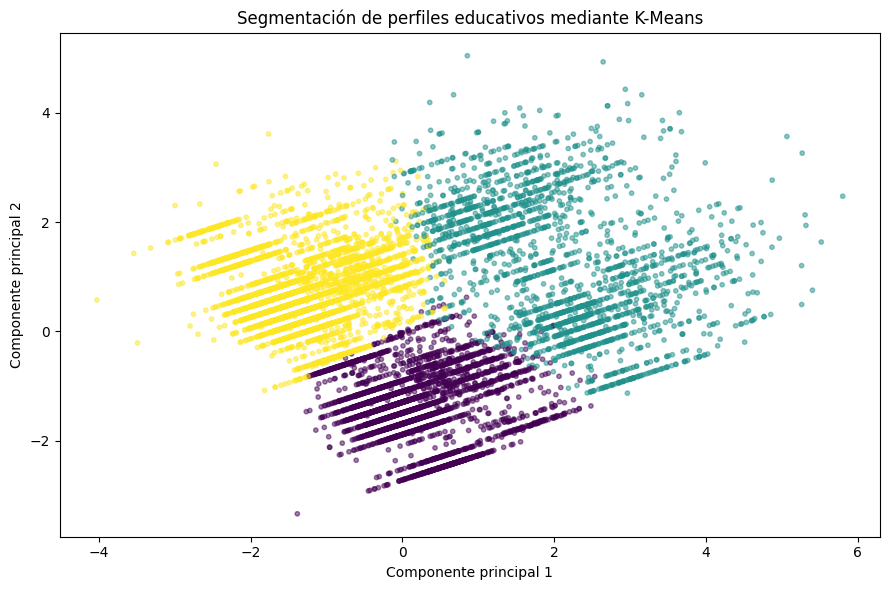


Cantidad por cluster:
Cluster
0    4070
1    2200
2    4178
Name: count, dtype: int64

CLUSTERING COMPLETADO


In [14]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ============================================================
# CLUSTERING DE PERFILES EDUCATIVOS
# ============================================================

cluster_df = eda.copy()

# Variables derivadas
cluster_df["Ingreso_log"] = np.log1p(cluster_df["yhogpc"])
cluster_df["Rural"] = (cluster_df["area"] == 2).astype(int)
cluster_df["Electricidad"] = (cluster_df["s06a_12"] == 1).astype(int)
cluster_df["Agua_Red"] = cluster_df["s06a_07"].isin([1, 2]).astype(int)
cluster_df["Autoidentifica"] = (cluster_df["s01a_09"] == 1).astype(int)

variables_cluster = [
    "s01a_03",        # Edad
    "Ingreso_log",
    "Rural",
    "Electricidad",
    "Agua_Red",
    "Autoidentifica",
    "niv_ed"
]

X_cluster = cluster_df[variables_cluster]

# Estandarización
scaler_cluster = StandardScaler()
X_scaled = scaler_cluster.fit_transform(X_cluster)

# K-Means con 3 grupos
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
)

cluster_df["Cluster"] = kmeans.fit_predict(X_scaled)

# ============================================================
# PERFIL DE CADA CLUSTER
# ============================================================

perfil_clusters = cluster_df.groupby("Cluster").agg(
    Personas=("Cluster", "size"),
    Edad_promedio=("s01a_03", "mean"),
    Ingreso_pc_mediano=("yhogpc", "median"),
    Rural_pct=("Rural", "mean"),
    Electricidad_pct=("Electricidad", "mean"),
    Agua_red_pct=("Agua_Red", "mean"),
    Autoidentifica_pct=("Autoidentifica", "mean"),
    No_asistencia_pct=("No_Asiste", "mean")
)

for columna in [
    "Rural_pct",
    "Electricidad_pct",
    "Agua_red_pct",
    "Autoidentifica_pct",
    "No_asistencia_pct"
]:
    perfil_clusters[columna] *= 100

print("=== PERFIL DE LOS CLUSTERS ===")
print(perfil_clusters.round(2))

# ============================================================
# PCA PARA VISUALIZACIÓN 2D
# ============================================================

pca = PCA(n_components=2)

componentes = pca.fit_transform(X_scaled)

cluster_df["PCA1"] = componentes[:, 0]
cluster_df["PCA2"] = componentes[:, 1]

plt.figure(figsize=(9,6))

plt.scatter(
    cluster_df["PCA1"],
    cluster_df["PCA2"],
    c=cluster_df["Cluster"],
    s=10,
    alpha=0.5
)

plt.title("Segmentación de perfiles educativos mediante K-Means")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.tight_layout()

plt.savefig(
    "06_clusters_perfiles_educativos.png",
    dpi=300
)

plt.show()

print("\nCantidad por cluster:")
print(cluster_df["Cluster"].value_counts().sort_index())

print("\nCLUSTERING COMPLETADO")

Entrenamiento: (8358, 11)
Prueba: (2090, 11)

Distribución prueba:
Riesgo_Desercion
0    1981
1     109
Name: count, dtype: int64

=== RESULTADOS DE LOS MODELOS ===
                Modelo  Accuracy  Precision  Recall      F1  AUC_ROC
0  Regresión Logística    0.8708     0.2693  0.8624  0.4105   0.9218
1        Random Forest    0.9464     0.4737  0.2477  0.3253   0.9086


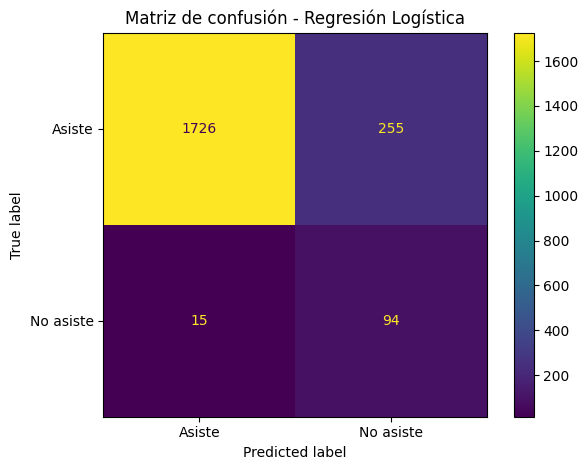

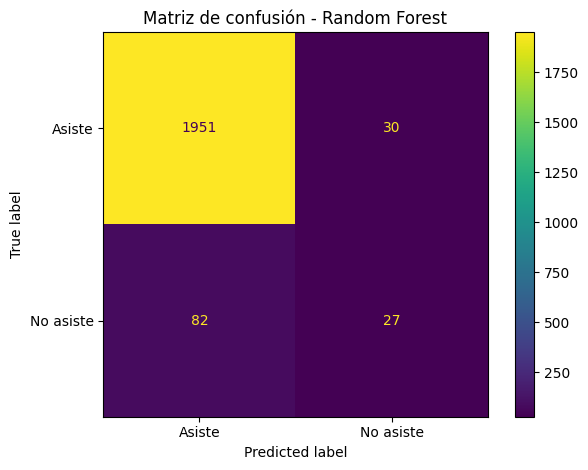


=== TOP 10 VARIABLES RANDOM FOREST ===
              Variable  Importancia
0         num__s01a_03     0.286591
1          num__yhogpc     0.140423
35     cat__niv_ed_4.0     0.085158
32     cat__niv_ed_1.0     0.061721
34     cat__niv_ed_3.0     0.027267
18  cat__s01a_07_1_6.0     0.021241
47    cat__s06a_07_1.0     0.020626
42    cat__s06a_06_5.0     0.017715
38    cat__s06a_06_1.0     0.016568
12      cat__depto_7.0     0.016254


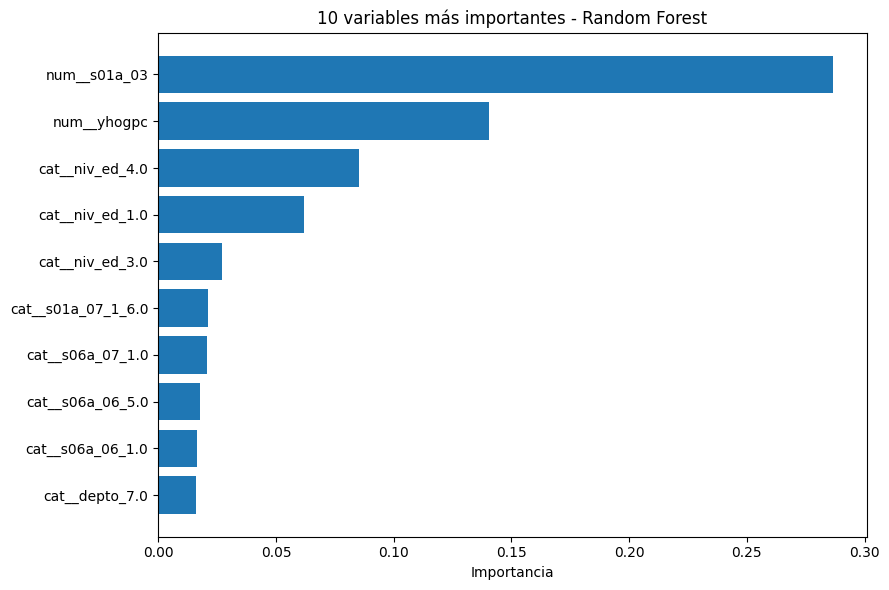


MACHINE LEARNING COMPLETADO


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ============================================================
# VARIABLE OBJETIVO
# 1 = NO ASISTE
# 0 = ASISTE
# ============================================================

ml = modelo.copy()
ml["Riesgo_Desercion"] = 1 - ml["Asistencia_Escolar"]

X = ml[
    [
        "s01a_03",
        "s01a_02",
        "area",
        "depto",
        "s01a_07_1",
        "s01a_09",
        "yhogpc",
        "niv_ed",
        "s06a_06",
        "s06a_07",
        "s06a_12"
    ]
]

y = ml["Riesgo_Desercion"]

numericas = [
    "s01a_03",
    "yhogpc"
]

categoricas = [
    "s01a_02",
    "area",
    "depto",
    "s01a_07_1",
    "s01a_09",
    "niv_ed",
    "s06a_06",
    "s06a_07",
    "s06a_12"
]

preprocesamiento = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numericas),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categoricas
        )
    ]
)

# ============================================================
# 80% ENTRENAMIENTO / 20% PRUEBA ESTRATIFICADO
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

print("\nDistribución prueba:")
print(y_test.value_counts())

# ============================================================
# MODELO 1 - REGRESIÓN LOGÍSTICA
# ============================================================

logistica = Pipeline(
    steps=[
        ("prep", preprocesamiento),
        (
            "modelo",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

logistica.fit(X_train, y_train)

pred_log = logistica.predict(X_test)
prob_log = logistica.predict_proba(X_test)[:,1]

# ============================================================
# MODELO 2 - RANDOM FOREST
# ============================================================

random_forest = Pipeline(
    steps=[
        ("prep", preprocesamiento),
        (
            "modelo",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ]
)

random_forest.fit(X_train, y_train)

pred_rf = random_forest.predict(X_test)
prob_rf = random_forest.predict_proba(X_test)[:,1]

# ============================================================
# MÉTRICAS
# ============================================================

def evaluar(nombre, y_real, pred, prob):
    return {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_real, pred),
        "Precision": precision_score(y_real, pred, zero_division=0),
        "Recall": recall_score(y_real, pred, zero_division=0),
        "F1": f1_score(y_real, pred, zero_division=0),
        "AUC_ROC": roc_auc_score(y_real, prob)
    }

resultados = pd.DataFrame([
    evaluar(
        "Regresión Logística",
        y_test,
        pred_log,
        prob_log
    ),
    evaluar(
        "Random Forest",
        y_test,
        pred_rf,
        prob_rf
    )
])

print("\n=== RESULTADOS DE LOS MODELOS ===")
print(resultados.round(4))

# ============================================================
# MATRICES DE CONFUSIÓN
# ============================================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_log,
    display_labels=["Asiste", "No asiste"]
)

plt.title("Matriz de confusión - Regresión Logística")
plt.tight_layout()
plt.savefig("07_matriz_logistica.png", dpi=300)
plt.show()

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_rf,
    display_labels=["Asiste", "No asiste"]
)

plt.title("Matriz de confusión - Random Forest")
plt.tight_layout()
plt.savefig("08_matriz_random_forest.png", dpi=300)
plt.show()

# ============================================================
# TOP 10 VARIABLES RANDOM FOREST
# ============================================================

prep_rf = random_forest.named_steps["prep"]
modelo_rf = random_forest.named_steps["modelo"]

nombres_variables = prep_rf.get_feature_names_out()

importancias = pd.DataFrame({
    "Variable": nombres_variables,
    "Importancia": modelo_rf.feature_importances_
})

top10 = (
    importancias
    .sort_values("Importancia", ascending=False)
    .head(10)
)

print("\n=== TOP 10 VARIABLES RANDOM FOREST ===")
print(top10)

plt.figure(figsize=(9,6))

plt.barh(
    top10["Variable"][::-1],
    top10["Importancia"][::-1]
)

plt.title("10 variables más importantes - Random Forest")
plt.xlabel("Importancia")
plt.tight_layout()

plt.savefig(
    "09_importancia_variables.png",
    dpi=300
)

plt.show()

print("\nMACHINE LEARNING COMPLETADO")

In [16]:
import folium
import pandas as pd

# ============================================================
# MAPA INTERACTIVO POR DEPARTAMENTO
# ============================================================

# Coordenadas referenciales de los departamentos
coordenadas = {
    "Chuquisaca": [-19.0333, -65.2627],
    "La Paz": [-16.4897, -68.1193],
    "Cochabamba": [-17.3895, -66.1568],
    "Oruro": [-17.9647, -67.1060],
    "Potosí": [-19.5836, -65.7531],
    "Tarija": [-21.5355, -64.7296],
    "Santa Cruz": [-17.7833, -63.1821],
    "Beni": [-14.8333, -64.9000],
    "Pando": [-11.0267, -68.7692]
}

# Resumen departamental
mapa_depto = eda.groupby("Departamento").agg(
    Personas=("No_Asiste", "size"),
    No_Asistencia=("No_Asiste", "mean"),
    Ingreso_PC=("yhogpc", "median")
).reset_index()

mapa_depto["No_Asistencia"] *= 100

# Tasas por área urbana/rural
zona = (
    eda.groupby(["Departamento", "Area"])["No_Asiste"]
    .mean()
    .mul(100)
    .unstack()
    .reset_index()
)

mapa_depto = mapa_depto.merge(
    zona,
    on="Departamento",
    how="left"
)

print("=== DATOS PARA EL MAPA ===")
print(mapa_depto.round(2))

# Crear mapa
m = folium.Map(
    location=[-16.5, -64.5],
    zoom_start=5,
    tiles="OpenStreetMap"
)

# Capa 1: tasa de no asistencia
capa_riesgo = folium.FeatureGroup(
    name="Tasa de no asistencia escolar"
)

for _, fila in mapa_depto.iterrows():

    lat, lon = coordenadas[fila["Departamento"]]

    urbana = fila.get("Urbana", float("nan"))
    rural = fila.get("Rural", float("nan"))

    popup = f"""
    <b>{fila['Departamento']}</b><br>
    No asistencia total: {fila['No_Asistencia']:.2f}%<br>
    Urbana: {urbana:.2f}%<br>
    Rural: {rural:.2f}%<br>
    Personas analizadas: {int(fila['Personas'])}<br>
    Ingreso PC mediano: Bs {fila['Ingreso_PC']:.2f}
    """

    folium.CircleMarker(
        location=[lat, lon],
        radius=6 + fila["No_Asistencia"],
        popup=folium.Popup(popup, max_width=300),
        tooltip=f"{fila['Departamento']}: {fila['No_Asistencia']:.2f}%",
        fill=True,
        fill_opacity=0.7
    ).add_to(capa_riesgo)

capa_riesgo.add_to(m)

# Capa 2: ingreso per cápita
capa_ingreso = folium.FeatureGroup(
    name="Ingreso per cápita mediano"
)

for _, fila in mapa_depto.iterrows():

    lat, lon = coordenadas[fila["Departamento"]]

    folium.Marker(
        location=[lat, lon],
        tooltip=(
            f"{fila['Departamento']} | "
            f"Ingreso PC: Bs {fila['Ingreso_PC']:.2f}"
        ),
        icon=folium.Icon(icon="info-sign")
    ).add_to(capa_ingreso)

capa_ingreso.add_to(m)

folium.LayerControl().add_to(m)

# Guardar mapa
m.save("10_mapa_interactivo_desercion.html")

display(m)

# ============================================================
# GUARDAR DATASET PROCESADO
# ============================================================

datos_finales = eda.copy()

datos_finales.to_csv(
    "EH2025_desercion_escolar_procesado.csv",
    index=False,
    encoding="utf-8-sig"
)

# Guardar resultados de modelos
resultados.to_csv(
    "resultados_modelos.csv",
    index=False,
    encoding="utf-8-sig"
)

# Guardar importancia de variables
top10.to_csv(
    "top10_variables_random_forest.csv",
    index=False,
    encoding="utf-8-sig"
)

# Si ya ejecutaste clustering
if "Cluster" in cluster_df.columns:
    cluster_df.to_csv(
        "datos_con_clusters.csv",
        index=False,
        encoding="utf-8-sig"
    )

    perfil_clusters.to_csv(
        "perfil_clusters.csv",
        encoding="utf-8-sig"
    )

print("\nARCHIVOS GENERADOS CORRECTAMENTE")
print("- 10_mapa_interactivo_desercion.html")
print("- EH2025_desercion_escolar_procesado.csv")
print("- resultados_modelos.csv")
print("- top10_variables_random_forest.csv")
print("- datos_con_clusters.csv")
print("- perfil_clusters.csv")

=== DATOS PARA EL MAPA ===
  Departamento  Personas  No_Asistencia  Ingreso_PC  Rural  Urbana
0         Beni       751           5.86     1039.33   9.14    4.78
1   Chuquisaca       745           5.50      880.00   9.41    2.22
2   Cochabamba      1625           3.63     1235.00   5.52    3.22
3       La Paz      2375           4.55     1104.88   7.21    4.11
4        Oruro       734           4.09      899.30   5.56    3.32
5        Pando       699           8.01     1172.27  11.43    4.58
6       Potosí       774           5.30      846.83   6.69    4.10
7   Santa Cruz      2028           6.11     1307.60  14.01    4.97
8       Tarija       717           5.72     1060.60  13.20    2.88



ARCHIVOS GENERADOS CORRECTAMENTE
- 10_mapa_interactivo_desercion.html
- EH2025_desercion_escolar_procesado.csv
- resultados_modelos.csv
- top10_variables_random_forest.csv
- datos_con_clusters.csv
- perfil_clusters.csv


In [17]:
# Recrear el mapa con otro proveedor de mapas
m = folium.Map(
    location=[-16.5, -64.5],
    zoom_start=5,
    tiles="CartoDB positron"
)

capa_riesgo = folium.FeatureGroup(
    name="Tasa de no asistencia escolar"
)

for _, fila in mapa_depto.iterrows():

    lat, lon = coordenadas[fila["Departamento"]]

    urbana = fila.get("Urbana", float("nan"))
    rural = fila.get("Rural", float("nan"))

    popup = f"""
    <b>{fila['Departamento']}</b><br>
    No asistencia total: {fila['No_Asistencia']:.2f}%<br>
    Urbana: {urbana:.2f}%<br>
    Rural: {rural:.2f}%<br>
    Personas analizadas: {int(fila['Personas'])}<br>
    Ingreso PC mediano: Bs {fila['Ingreso_PC']:.2f}
    """

    folium.CircleMarker(
        location=[lat, lon],
        radius=6 + fila["No_Asistencia"],
        popup=popup,
        tooltip=f"{fila['Departamento']}: {fila['No_Asistencia']:.2f}%",
        fill=True,
        fill_opacity=0.7
    ).add_to(capa_riesgo)

capa_riesgo.add_to(m)

folium.LayerControl().add_to(m)

m.save("10_mapa_interactivo_desercion.html")

display(m)

In [18]:
print("=== PERFIL DE LOS CLUSTERS ===")
print(perfil_clusters.round(2))

=== PERFIL DE LOS CLUSTERS ===
         Personas  Edad_promedio  Ingreso_pc_mediano  Rural_pct  \
Cluster                                                           
0            4070           9.18             1178.33       5.04   
1            2200          12.06              619.33      97.68   
2            4178          15.83             1352.22       5.03   

         Electricidad_pct  Agua_red_pct  Autoidentifica_pct  No_asistencia_pct  
Cluster                                                                         
0                   99.85         87.89                5.50               1.01  
1                   88.18          8.45               25.68               8.27  
2                   99.88         88.20                9.12               7.68  


In [19]:
# ============================================================
# MAPA INTERACTIVO FINAL CON ESRI
# ============================================================

m = folium.Map(
    location=[-16.5, -64.5],
    zoom_start=5,
    tiles=None
)

folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Street_Map/MapServer/tile/{z}/{y}/{x}",
    attr="Tiles © Esri",
    name="Esri World Street Map"
).add_to(m)

# Cluster dominante por departamento
cluster_depto = (
    cluster_df.groupby(["Departamento", "Cluster"])
    .size()
    .unstack(fill_value=0)
)

cluster_depto["Cluster_Dominante"] = cluster_depto.idxmax(axis=1)

cluster_depto = cluster_depto.reset_index()

nombres_cluster = {
    0: "Perfil urbano joven - bajo riesgo",
    1: "Perfil rural vulnerable - mayor riesgo",
    2: "Perfil urbano adolescente - riesgo elevado"
}

mapa_final = mapa_depto.merge(
    cluster_depto[["Departamento", "Cluster_Dominante"]],
    on="Departamento",
    how="left"
)

mapa_final["Perfil"] = (
    mapa_final["Cluster_Dominante"]
    .map(nombres_cluster)
)

for _, fila in mapa_final.iterrows():

    lat, lon = coordenadas[fila["Departamento"]]

    popup = f"""
    <b>{fila['Departamento']}</b><br>
    No asistencia total: {fila['No_Asistencia']:.2f}%<br>
    Rural: {fila['Rural']:.2f}%<br>
    Urbana: {fila['Urbana']:.2f}%<br>
    Ingreso PC mediano: Bs {fila['Ingreso_PC']:.2f}<br>
    Cluster dominante: {fila['Perfil']}
    """

    folium.CircleMarker(
        location=[lat, lon],
        radius=7 + fila["No_Asistencia"],
        popup=folium.Popup(popup, max_width=350),
        tooltip=f"{fila['Departamento']} - {fila['No_Asistencia']:.2f}%",
        fill=True,
        fill_opacity=0.75
    ).add_to(m)

folium.LayerControl().add_to(m)

m.save("10_mapa_interactivo_desercion.html")

display(m)

print("MAPA FINAL GENERADO")

MAPA FINAL GENERADO


## Conclusiones del análisis

El análisis se realizó sobre 10.448 personas de 6 a 19 años de la Encuesta de Hogares 2025.

La tasa de no asistencia escolar observada fue de 5,21%. Se identificaron diferencias importantes según características demográficas, geográficas y socioeconómicas.

### Principales hallazgos

- La no asistencia fue mayor en el área rural (8,93%) que en el área urbana (4,00%).
- Pando presentó la mayor tasa departamental observada (8,01%), mientras Cochabamba presentó la menor (3,63%).
- La no asistencia aumenta principalmente en las edades mayores: 18 años registró 18,73% y 19 años 37,18%.
- Los hombres presentaron una tasa de no asistencia de 5,44% y las mujeres de 4,97%.
- El clustering identificó tres perfiles diferenciados.
- El Cluster 1 presentó un perfil predominantemente rural, menor ingreso per cápita y una tasa de no asistencia de 8,27%.
- El Cluster 2 agrupó principalmente adolescentes de mayor edad y presentó una tasa de no asistencia de 7,68%.

### Modelos predictivos

La Regresión Logística alcanzó:

- Accuracy: 87,08%
- Precision: 26,93%
- Recall: 86,24%
- F1: 41,05%
- AUC-ROC: 92,18%

Random Forest alcanzó:

- Accuracy: 94,64%
- Precision: 47,37%
- Recall: 24,77%
- F1: 32,53%
- AUC-ROC: 90,86%

Debido al desbalance de clases, el accuracy por sí solo no es suficiente para evaluar los modelos. La Regresión Logística mostró una mayor capacidad para identificar a las personas que no asisten al sistema educativo, reflejada principalmente en su recall.

### Variables predictivas relevantes

En Random Forest, las variables con mayor importancia predictiva fueron principalmente:

1. Edad
2. Ingreso per cápita del hogar
3. Nivel educativo
4. Idioma
5. Acceso al agua
6. Material del piso
7. Departamento

Estas asociaciones deben interpretarse como relaciones predictivas y no como relaciones causales.

### Opciones de política pública vinculadas a los resultados

A partir de los patrones observados, pueden considerarse para evaluación:

1. Focalización de mecanismos de permanencia educativa en adolescentes de 17 a 19 años.
2. Análisis diferenciado de intervenciones para áreas rurales, donde la no asistencia observada fue mayor.
3. Priorización del seguimiento territorial en departamentos y perfiles socioeconómicos donde se observaron mayores tasas de no asistencia.

Estas medidas requerirían evaluación adicional antes de su implementación, ya que el análisis identifica asociaciones estadísticas y perfiles de riesgo, no efectos causales.

In [20]:
# ============================================================
# CIERRE PARTE 1 - PREPROCESAMIENTO Y DATASET FINAL
# ============================================================

import numpy as np
import pandas as pd

print("=== ESTRUCTURA DE LAS BASES ===")
print("Persona:", persona.shape)
print("Vivienda:", vivienda.shape)
print("Dataset analítico:", modelo.shape)

print("\n=== TIPOS DE DATOS ===")
print(modelo.dtypes)

print("\n=== ESTADÍSTICOS DESCRIPTIVOS ===")
display(modelo.describe().T)

print("\n=== VALORES FALTANTES ===")
print(modelo.isnull().sum())

print("\n=== TOTAL DE VALORES FALTANTES ===")
print(modelo.isnull().sum().sum())

# ============================================================
# INGENIERÍA DE CARACTERÍSTICAS
# ============================================================

dataset_final = modelo.copy()

dataset_final["Grupo_Edad"] = pd.cut(
    dataset_final["s01a_03"],
    bins=[5, 11, 14, 16, 19],
    labels=[
        "6-11 años",
        "12-14 años",
        "15-16 años",
        "17-19 años"
    ]
)

dataset_final["Ingreso_log"] = np.log1p(
    dataset_final["yhogpc"]
)

dataset_final["Rural"] = (
    dataset_final["area"] == 2
).astype(int)

dataset_final["Tiene_Electricidad"] = (
    dataset_final["s06a_12"] == 1
).astype(int)

dataset_final["Agua_Red"] = (
    dataset_final["s06a_07"].isin([1, 2])
).astype(int)

dataset_final["Riesgo_Desercion"] = (
    1 - dataset_final["Asistencia_Escolar"]
)

print("\n=== VARIABLES CREADAS ===")
print([
    "Grupo_Edad",
    "Ingreso_log",
    "Rural",
    "Tiene_Electricidad",
    "Agua_Red",
    "Riesgo_Desercion"
])

# ============================================================
# GUARDAR DATASET PROCESADO
# ============================================================

dataset_final.to_csv(
    "dataset_procesado.csv",
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# GENERAR ARCHIVO DE PREDICCIONES
# ============================================================

predicciones = X_test.copy()

predicciones["Real_No_Asiste"] = y_test
predicciones["Pred_Logistica"] = pred_log
predicciones["Prob_Logistica"] = prob_log
predicciones["Pred_RandomForest"] = pred_rf
predicciones["Prob_RandomForest"] = prob_rf

predicciones.to_csv(
    "predicciones.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n=== ARCHIVOS GENERADOS ===")
print("dataset_procesado.csv:", dataset_final.shape)
print("predicciones.csv:", predicciones.shape)

print("\nPARTE 1 Y ARCHIVO DE PREDICCIONES COMPLETADOS")

=== ESTRUCTURA DE LAS BASES ===
Persona: (39485, 276)
Vivienda: (12726, 64)
Dataset analítico: (10448, 12)

=== TIPOS DE DATOS ===
Asistencia_Escolar      int64
s01a_03               float64
s01a_02               float64
area                  float64
depto                 float64
s01a_07_1             float64
s01a_09               float64
yhogpc                float64
niv_ed                float64
s06a_06               float64
s06a_07               float64
s06a_12               float64
dtype: object

=== ESTADÍSTICOS DESCRIPTIVOS ===


,count,mean,std,min,25%,50%,75%,max
Asistencia_Escolar,10448.0,0.947933,0.222174,0.0,1.0,1.0,1.000000,1.000000
s01a_03,10448.0,12.445731,3.846077,6.0,9.0,12.0,16.000000,19.000000
s01a_02,10448.0,1.487653,0.499871,1.0,1.0,1.0,2.000000,2.000000
area,10448.0,1.245406,0.430348,1.0,1.0,1.0,1.000000,2.000000
depto,10448.0,4.591596,2.505060,1.0,2.0,4.0,7.000000,9.000000
s01a_07_1,10448.0,9.797952,52.237264,2.0,6.0,6.0,6.000000,995.000000
s01a_09,10448.0,1.888017,0.315361,1.0,2.0,2.0,2.000000,2.000000
yhogpc,10448.0,1433.485066,1680.496874,0.0,700.0,1122.5,1804.619873,73979.398438
niv_ed,10448.0,1.973105,1.192790,0.0,1.0,2.0,3.000000,6.000000
s06a_06,10448.0,5.309342,2.171022,1.0,5.0,5.0,8.000000,9.000000



=== VALORES FALTANTES ===
Asistencia_Escolar    0
s01a_03               0
s01a_02               0
area                  0
depto                 0
s01a_07_1             0
s01a_09               0
yhogpc                0
niv_ed                0
s06a_06               0
s06a_07               0
s06a_12               0
dtype: int64

=== TOTAL DE VALORES FALTANTES ===
0

=== VARIABLES CREADAS ===
['Grupo_Edad', 'Ingreso_log', 'Rural', 'Tiene_Electricidad', 'Agua_Red', 'Riesgo_Desercion']

=== ARCHIVOS GENERADOS ===
dataset_procesado.csv: (10448, 18)
predicciones.csv: (2090, 16)

PARTE 1 Y ARCHIVO DE PREDICCIONES COMPLETADOS


In [21]:
import plotly.express as px

# ============================================================
# VISUALIZACIÓN INTERACTIVA 1 - ÁREA
# ============================================================

area_plot = (
    eda.groupby("Area")["No_Asiste"]
    .mean()
    .mul(100)
    .reset_index(name="Tasa_No_Asistencia")
)

fig1 = px.bar(
    area_plot,
    x="Area",
    y="Tasa_No_Asistencia",
    title="Tasa de no asistencia escolar por área",
    labels={
        "Area": "Área",
        "Tasa_No_Asistencia": "No asistencia (%)"
    },
    text_auto=".2f"
)

fig1.show()
fig1.write_html("11_interactivo_area.html")


# ============================================================
# VISUALIZACIÓN INTERACTIVA 2 - DEPARTAMENTO
# ============================================================

depto_plot = (
    eda.groupby("Departamento")["No_Asiste"]
    .mean()
    .mul(100)
    .reset_index(name="Tasa_No_Asistencia")
    .sort_values("Tasa_No_Asistencia")
)

fig2 = px.bar(
    depto_plot,
    x="Tasa_No_Asistencia",
    y="Departamento",
    orientation="h",
    title="Tasa de no asistencia escolar por departamento",
    labels={
        "Tasa_No_Asistencia": "No asistencia (%)"
    },
    text_auto=".2f"
)

fig2.show()
fig2.write_html("12_interactivo_departamento.html")


# ============================================================
# VISUALIZACIÓN INTERACTIVA 3 - EDAD
# ============================================================

edad_plot = (
    eda.groupby("s01a_03")["No_Asiste"]
    .mean()
    .mul(100)
    .reset_index(name="Tasa_No_Asistencia")
)

fig3 = px.line(
    edad_plot,
    x="s01a_03",
    y="Tasa_No_Asistencia",
    markers=True,
    title="No asistencia escolar según edad",
    labels={
        "s01a_03": "Edad",
        "Tasa_No_Asistencia": "No asistencia (%)"
    }
)

fig3.show()
fig3.write_html("13_interactivo_edad.html")


# ============================================================
# VISUALIZACIÓN INTERACTIVA 4 - CLUSTERS
# ============================================================

fig4 = px.scatter(
    cluster_df,
    x="PCA1",
    y="PCA2",
    color=cluster_df["Cluster"].astype(str),
    hover_data=[
        "s01a_03",
        "yhogpc",
        "Area",
        "Departamento",
        "No_Asiste"
    ],
    title="Clusters de perfiles educativos",
    labels={
        "PCA1": "Componente principal 1",
        "PCA2": "Componente principal 2",
        "color": "Cluster"
    }
)

fig4.show()
fig4.write_html("14_interactivo_clusters.html")

print("4 VISUALIZACIONES INTERACTIVAS GENERADAS CORRECTAMENTE")

4 VISUALIZACIONES INTERACTIVAS GENERADAS CORRECTAMENTE


In [22]:
import os
import shutil

# ============================================================
# ESTRUCTURA FINAL DEL PROYECTO
# ============================================================

proyecto = "Proyecto_EH2025_ML_Caso1"

carpetas = [
    f"{proyecto}/data",
    f"{proyecto}/notebooks",
    f"{proyecto}/outputs",
    f"{proyecto}/outputs/imagenes",
    f"{proyecto}/docs"
]

for carpeta in carpetas:
    os.makedirs(carpeta, exist_ok=True)

# ============================================================
# COPIAR ARCHIVOS GENERADOS
# ============================================================

archivos_data = [
    "dataset_procesado.csv"
]

archivos_outputs = [
    "predicciones.csv",
    "resultados_modelos.csv",
    "top10_variables_random_forest.csv",
    "perfil_clusters.csv",
    "10_mapa_interactivo_desercion.html",
    "11_interactivo_area.html",
    "12_interactivo_departamento.html",
    "13_interactivo_edad.html",
    "14_interactivo_clusters.html"
]

imagenes = [
    "01_asistencia_escolar.png",
    "02_no_asistencia_sexo.png",
    "03_no_asistencia_area.png",
    "04_no_asistencia_departamento.png",
    "05_no_asistencia_edad.png",
    "06_clusters_perfiles_educativos.png",
    "07_matriz_logistica.png",
    "08_matriz_random_forest.png",
    "09_importancia_variables.png"
]

for archivo in archivos_data:
    if os.path.exists(archivo):
        shutil.copy(archivo, f"{proyecto}/data/{archivo}")

for archivo in archivos_outputs:
    if os.path.exists(archivo):
        shutil.copy(archivo, f"{proyecto}/outputs/{archivo}")

for archivo in imagenes:
    if os.path.exists(archivo):
        shutil.copy(
            archivo,
            f"{proyecto}/outputs/imagenes/{archivo}"
        )

# ============================================================
# README
# ============================================================

readme = """# Análisis de la Deserción Escolar en Bolivia - EH2025

## Descripción

Proyecto desarrollado utilizando los microdatos de la Encuesta de Hogares 2025
del Instituto Nacional de Estadística de Bolivia.

El objetivo es analizar factores sociodemográficos, económicos y geográficos
asociados a la no asistencia escolar en personas de 6 a 19 años.

## Caso de estudio

Caso 1: Análisis de la Deserción Escolar en Bolivia.

Variable principal:

- Asistencia_Escolar
- 1 = Asiste
- 0 = No asiste

Para el modelado predictivo se creó:

- Riesgo_Desercion
- 1 = No asiste
- 0 = Asiste

## Datos utilizados

Se utilizaron:

- EH2025_Persona
- EH2025_Vivienda

Los datos fueron integrados mediante el identificador anonimizado del hogar.

Dataset analítico final: 10.448 registros.

## Análisis realizado

- Limpieza y preprocesamiento
- Ingeniería de características
- Análisis exploratorio de datos
- Visualizaciones estáticas e interactivas
- Mapa interactivo
- Clustering K-Means
- Regresión Logística
- Random Forest
- Evaluación con Accuracy, Precision, Recall, F1 y AUC-ROC
- Matrices de confusión
- Importancia de variables

## Principales resultados

La tasa observada de no asistencia escolar fue de 5,21%.

El área rural presentó una tasa de 8,93%, frente a 4,00% del área urbana.

La no asistencia aumenta considerablemente en las edades mayores:
18 años = 18,73% y 19 años = 37,18%.

La Regresión Logística obtuvo:

- Accuracy: 87,08%
- Precision: 26,93%
- Recall: 86,24%
- F1: 41,05%
- AUC-ROC: 92,18%

Random Forest obtuvo:

- Accuracy: 94,64%
- Precision: 47,37%
- Recall: 24,77%
- F1: 32,53%
- AUC-ROC: 90,86%

## Estructura

Proyecto_EH2025_ML_Caso1/

- data/
  - dataset_procesado.csv
- notebooks/
  - EH2025_Analisis_ML.ipynb
- outputs/
  - storytelling.pdf
  - predicciones.csv
  - resultados_modelos.csv
  - top10_variables_random_forest.csv
  - perfil_clusters.csv
  - mapas y visualizaciones interactivas
  - imagenes/
- docs/
  - README.md
- requirements.txt

## Fuente

Instituto Nacional de Estadística de Bolivia.
Encuesta de Hogares 2025 (EH2025).

## Autor

Daysi Maribel Quispe Guarachi
"""

with open(
    f"{proyecto}/docs/README.md",
    "w",
    encoding="utf-8"
) as f:
    f.write(readme)

# README también en la raíz para que GitHub lo muestre automáticamente
with open(
    f"{proyecto}/README.md",
    "w",
    encoding="utf-8"
) as f:
    f.write(readme)

# ============================================================
# REQUIREMENTS
# ============================================================

requirements = """pandas
numpy
matplotlib
plotly
folium
scikit-learn
pyreadstat
"""

with open(
    f"{proyecto}/requirements.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(requirements)

print("ESTRUCTURA DEL PROYECTO GENERADA CORRECTAMENTE")

for raiz, dirs, files in os.walk(proyecto):
    nivel = raiz.replace(proyecto, "").count(os.sep)
    sangria = "  " * nivel
    print(f"{sangria}{os.path.basename(raiz)}/")
    for archivo in files:
        print(f"{sangria}  {archivo}")

ESTRUCTURA DEL PROYECTO GENERADA CORRECTAMENTE
Proyecto_EH2025_ML_Caso1/
  requirements.txt
  README.md
  outputs/
    top10_variables_random_forest.csv
    predicciones.csv
    10_mapa_interactivo_desercion.html
    resultados_modelos.csv
    12_interactivo_departamento.html
    13_interactivo_edad.html
    11_interactivo_area.html
    14_interactivo_clusters.html
    perfil_clusters.csv
    imagenes/
      02_no_asistencia_sexo.png
      05_no_asistencia_edad.png
      08_matriz_random_forest.png
      07_matriz_logistica.png
      06_clusters_perfiles_educativos.png
      09_importancia_variables.png
      03_no_asistencia_area.png
      04_no_asistencia_departamento.png
      01_asistencia_escolar.png
  data/
    dataset_procesado.csv
  docs/
    README.md
  notebooks/
